In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
data = pd.read_csv("final_onshore_data_2017_2025.csv")
data["date"] = data['full_datetime'].str.rsplit('-', n=1).str[0]
data[['date', 'hour']] = data['correct_days'].str.rsplit('-', n=1, expand=True)
data['hour'] = data['hour'].astype(int) - 1
data['datetime'] = pd.to_datetime(data['date']) + pd.to_timedelta(data['hour'], unit='H')
data = data[data["date"] < "2025-01-01"]

data['month'] = data['datetime'].dt.to_period('M').astype(str)

start_date = pd.Timestamp('2017-01-01')
data['week_number'] = ((data['datetime'] - start_date).dt.days // 7) + 1

# Set 'datetime' as index for the dataset
data.set_index('datetime', inplace=True)

data["max_capacity"] = data["capacity"] / data["percentage"]
data["log_volume"] = np.log1p(data["volume"])
data["ratio_VC"] = data["volume"] / data["max_capacity"]


/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_3253/1161484966.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  data['datetime'] = pd.to_datetime(data['date']) + pd.to_timedelta(data['hour'], unit='H')


In [3]:
data.head()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor,correct_days,date,month,week_number,max_capacity,log_volume,ratio_VC
datetime,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,20170101,0,207.708194,49.666667,49.666667,10234.526316,98.076923,2017-01-01-01,679334,679334,0.788730,0,0,2017-01-01-01,2017-01-01,2017-01,1,861301.051331,13.428870,0.788730
2017-01-01 01:00:00,20170101,1,205.010321,50.000000,51.333333,10227.789474,98.153846,2017-01-01-02,677462,677462,0.786558,0,0,2017-01-01-02,2017-01-01,2017-01,1,861299.514778,13.426110,0.786558
2017-01-01 02:00:00,20170101,2,202.701006,51.666667,51.000000,10219.473684,98.230769,2017-01-01-03,653746,653746,0.759025,0,0,2017-01-01-03,2017-01-01,2017-01,1,861297.084050,13.390476,0.759025
2017-01-01 03:00:00,20170101,3,201.007553,52.333333,54.666667,10211.368421,98.038462,2017-01-01-04,705882,705882,0.819552,0,0,2017-01-01-04,2017-01-01,2017-01,1,861302.267903,13.467205,0.819552
2017-01-01 04:00:00,20170101,4,200.325015,52.666667,53.333333,10203.526316,97.461538,2017-01-01-05,716738,716738,0.832158,0,0,2017-01-01-05,2017-01-01,2017-01,1,861300.347955,13.482467,0.832158


In [4]:
len(data)

70128

In [5]:
X = data.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y = data["volume"]
y_log = data["log_volume"]
X_train = X[X["date"] < "2024-01-01"]
X_test = X[X["date"] >= "2024-01-01"]

# Label
y_train = y[:X_train.shape[0]] #list slice: from beginning to end of X-train
y_test = y[X_train.shape[0]:] #list slice: from end of X-train to the end of the data
y_train_log = y_log[:X_train.shape[0]]
y_test_log = y_log[X_train.shape[0]:]

In [6]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(61344, 15)
(61344,)
(8784,)
(8784, 15)
(61344,)
(8784,)


In [7]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "max_capacity"]
X_train = X_train.loc[:, numeric_features]
X_test = X_test.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm = preprocessor.fit_transform(X_train)
X_test_norm = preprocessor.fit_transform(X_test)
X_train = pd.DataFrame(X_train_norm, columns=X_train.columns.values, index=X_train.index.values)
X_test = pd.DataFrame(X_test_norm, columns = X_test.columns.values, index=X_test.index.values)


In [8]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)

(61344, 7)
(61344,)
(8784,)
(8784, 7)


In [10]:
param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [50]
}
model = XGBRegressor()
grid = GridSearchCV(model, param_grid=param_grid, cv=3)
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'max_depth': [3, 5], 'n_estimators': [50]})

In [9]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB.fit(X_train, y_train) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model = cv_XGB.best_estimator_
XGB_pred = XGB_model.predict(X_test)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test, XGB_pred))


Mean cross-validated score of the best_estimator: 0.9364969047820966
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  2166667389592.8184


# Logged version

In [10]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_log.fit(X_train, y_train_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_log = cv_XGB_log.best_estimator_
XGB_pred_log = XGB_model_log.predict(X_test)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_log, XGB_pred_log))


Mean cross-validated score of the best_estimator: 0.9954323724291946
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  5.783949820109207


In [11]:
x_axis_train = data["date"][:len(y_train_log)]
x_axis_test = data["date"][len(y_train_log):]
x_axis_train[0:5]
print(len(x_axis_train))
print(len(x_axis_test))

61344
8784


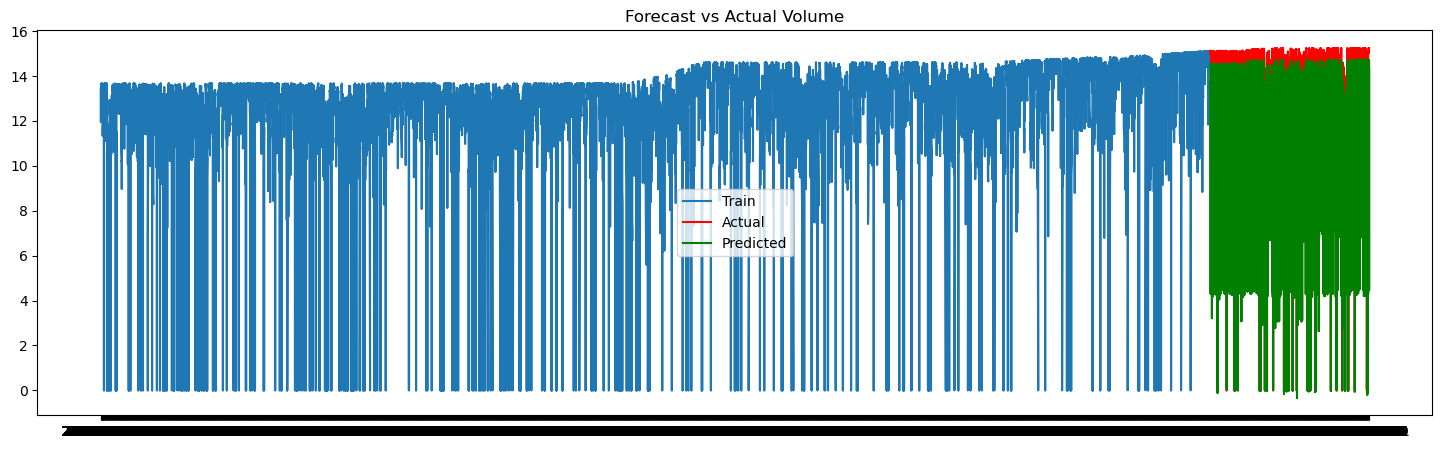

In [12]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train, y_train_log, label="Train")
plt.plot(x_axis_test, y_test_log, label="Actual", color='red')
plt.plot(x_axis_test, XGB_pred_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Monthly

In [13]:
# Convert hourly data to monthly data
db_monthly = data.groupby('month').mean(numeric_only=True)
# Split into train and test set
train_db = db_monthly[db_monthly.index <= '2024-06']
test_db = db_monthly[db_monthly.index > '2024-06']

X_month = db_monthly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y_month_log = db_monthly["log_volume"]
y_month = db_monthly["volume"]

# Features
X_train_month = X_month[X_month.index <= '2024-06']
X_test_month = X_month[(X_month.index > '2024-06')]

# Label log
y_train_month_log = y_month_log[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month_log = y_month_log[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data

# Label
y_train_month = y_month[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month = y_month[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data


In [14]:
db_monthly.head()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,capacity,volume,percentage,emission,emissionfactor,week_number,max_capacity,log_volume,ratio_VC
month,,,,,,,,,,,,,,,,
2017-01,20170116.0,11.5,185.731777,36.941244,36.996098,10228.397969,87.256987,400762.516129,400762.516129,0.465300,0.0,0.0,2.741935,861300.046159,11.679724,0.492437
2017-02,20170214.5,11.5,164.843658,50.570396,50.605399,10151.514753,85.539303,580108.617560,580108.617560,0.673527,0.0,0.0,6.928571,861301.737837,12.844484,0.685773
2017-03,20170316.0,11.5,188.493760,45.367780,45.458787,10155.116381,78.163972,412925.348118,412925.348118,0.479421,0.0,0.0,11.129032,861299.766603,12.440796,0.486616
2017-04,20170415.5,11.5,236.862021,38.027719,38.274926,10211.061356,74.574933,381875.052778,381875.052778,0.443371,0.0,0.0,15.500000,861299.510125,11.599916,0.481488
2017-05,20170516.0,11.5,167.468880,36.510271,36.609297,10170.346032,73.232587,318924.645161,318924.645161,0.370283,0.0,0.0,19.870968,861299.841886,11.941363,0.381566


In [15]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 10)
(6, 10)
(90,)
(6,)
(90,)
(6,)


In [16]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "max_capacity"]
X_train_month = X_train_month.loc[:, numeric_features]
X_test_month = X_test_month.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_month = preprocessor.fit_transform(X_train_month)
X_test_norm_month = preprocessor.fit_transform(X_test_month)


In [17]:
#add feature names back 
X_train_month = pd.DataFrame(X_train_norm_month, columns=X_train_month.columns.values, index=X_train_month.index.values)

X_test_month = pd.DataFrame(X_test_norm_month, columns = X_test_month.columns.values, index=X_test_month.index.values)

X_train_month.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,max_capacity
2017-01,-0.118193,-0.636291,-0.648399,1.708561,1.078912,-0.297349,-1.055322
2017-02,-0.837620,1.114575,1.103968,-0.027933,0.835453,0.673506,-1.055319
2017-03,-0.023064,0.446222,0.441277,0.053414,-0.209903,-0.231508,-1.055322
2017-04,1.642833,-0.496717,-0.483734,1.316994,-0.718602,-0.399593,-1.055323
2017-05,-0.747203,-0.691656,-0.698205,0.397393,-0.908862,-0.740363,-1.055322


In [18]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)
print(y_train_month.shape)
print(y_test_month.shape)

(90, 7)
(6, 7)
(90,)
(6,)
(90,)
(6,)


In [19]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month.fit(X_train_month, y_train_month) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month = cv_XGB_month.best_estimator_
XGB_pred_month = XGB_model_month.predict(X_test_month)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month, XGB_pred_month))

Mean cross-validated score of the best_estimator: 0.5100659343956664
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1407781061720.1575


In [20]:
x_axis_train_m = db_monthly["year_mon_day"][:len(y_train_month)]
x_axis_test_m = db_monthly["year_mon_day"][len(y_train_month):]
x_axis_train[0:5]
print(len(x_axis_train_m))
print(len(x_axis_test_m))

90
6


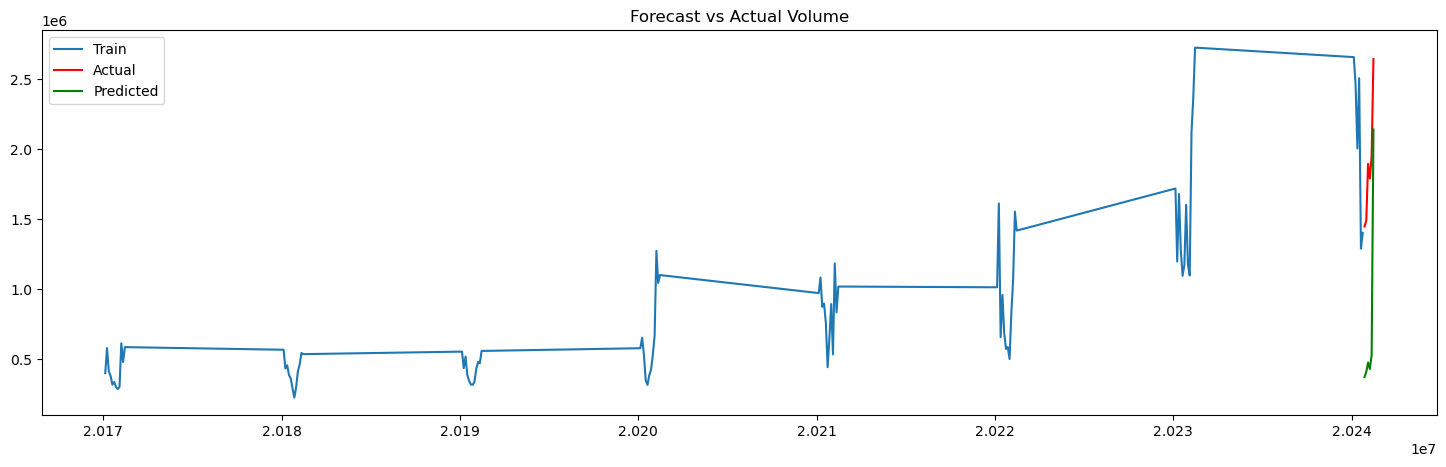

In [21]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_m, y_train_month, label="Train")
plt.plot(x_axis_test_m, y_test_month, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [22]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_log.fit(X_train_month, y_train_month_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_log = cv_XGB_month_log.best_estimator_
XGB_pred_month_log = XGB_model_month_log.predict(X_test_month)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month_log, XGB_pred_month_log))


Mean cross-validated score of the best_estimator: 0.6112089018233864
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1.5391492253439125


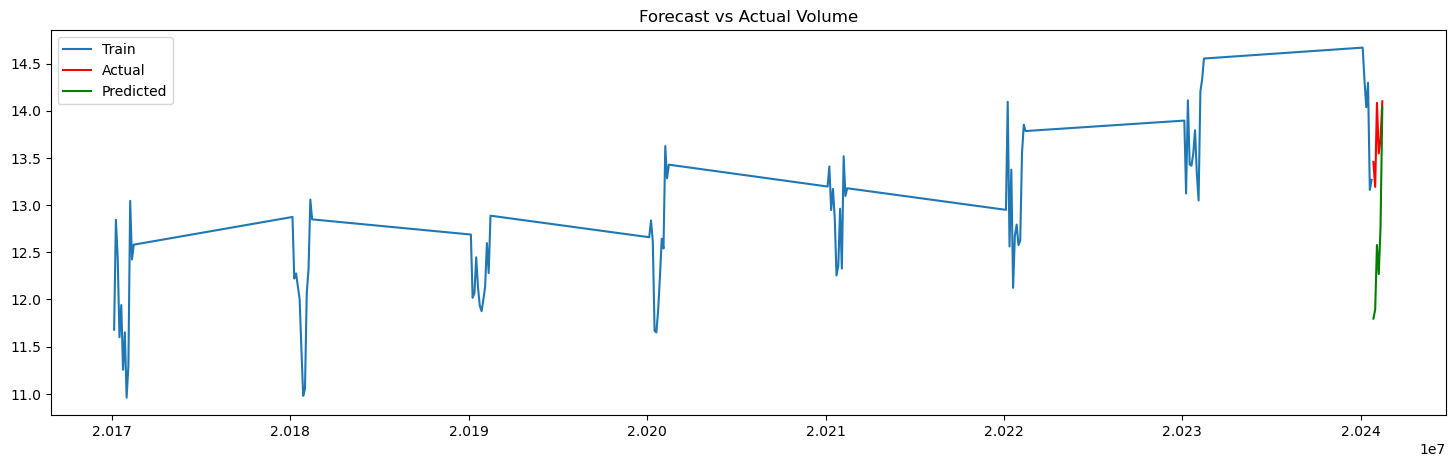

In [23]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_m, y_train_month_log, label="Train")
plt.plot(x_axis_test_m, y_test_month_log, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Weekly

In [24]:
# Convert hourly data to weekly data
db_weekly = data.groupby('week_number').mean(numeric_only=True)

X_week = db_weekly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y_week = db_weekly["volume"]
y_week_log = db_weekly["log_volume"]

# Features
X_train_week = X_week[X_week.index <= 406]
X_test_week = X_week[(X_week.index > 406)]

# Label
y_train_week = y_week[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week = y_week[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

# Label Log
y_train_week_log = y_week_log[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week_log = y_week_log[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

In [25]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 9)
(12, 9)
(406,)
(12,)
(406,)
(12,)


In [26]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "max_capacity"]
X_train_week = X_train_week.loc[:, numeric_features]
X_test_week = X_test_week.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_week = preprocessor.fit_transform(X_train_week)
X_test_norm_week = preprocessor.fit_transform(X_test_week)

In [27]:
#add feature names back 
X_train_week = pd.DataFrame(X_train_norm_week, columns=X_train_week.columns.values, index=X_train_week.index.values)

X_test_week = pd.DataFrame(X_test_norm_week, columns = X_test_week.columns.values, index=X_test_week.index.values)

X_train_week.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,max_capacity
1,0.754089,0.260348,0.250430,1.449833,0.856013,0.632967,-1.092386
2,1.121871,0.952337,0.942725,-0.502782,1.113559,0.580381,-1.092387
3,-1.670114,-1.719447,-1.734724,2.312354,1.057873,-1.585634,-1.092382
4,-0.500724,-1.217966,-1.214146,1.188497,0.599298,-0.741599,-1.092388
5,-0.476538,-0.061460,-0.068496,-0.802520,1.052702,0.148364,-1.092385


In [28]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 7)
(12, 7)
(406,)
(12,)
(406,)
(12,)


In [29]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week.fit(X_train_week, y_train_week) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week = cv_XGB_week.best_estimator_
XGB_pred_week = XGB_model_week.predict(X_test_week)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week, XGB_pred_week))


Mean cross-validated score of the best_estimator: 0.9227008333532387
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1779784176560.4114


In [30]:
x_axis_train_w = db_weekly["year_mon_day"][:len(y_train_week)]
x_axis_test_w = db_weekly["year_mon_day"][len(y_train_week):]
print(len(x_axis_train_w))
print(len(x_axis_test_w))

406
12


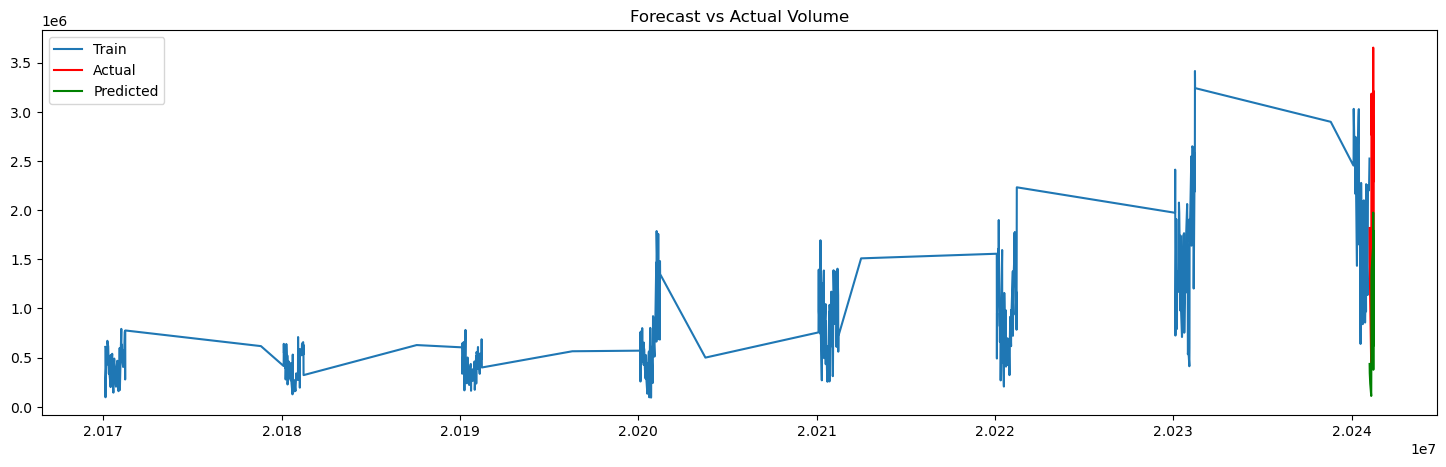

In [31]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_w, y_train_week, label="Train")
plt.plot(x_axis_test_w, y_test_week, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [32]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_log.fit(X_train_week, y_train_week_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_log = cv_XGB_week_log.best_estimator_
XGB_pred_week_log = XGB_model_week_log.predict(X_test_week)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week_log, XGB_pred_week_log))


Mean cross-validated score of the best_estimator: 0.7302524416926033
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1.7185718536705534


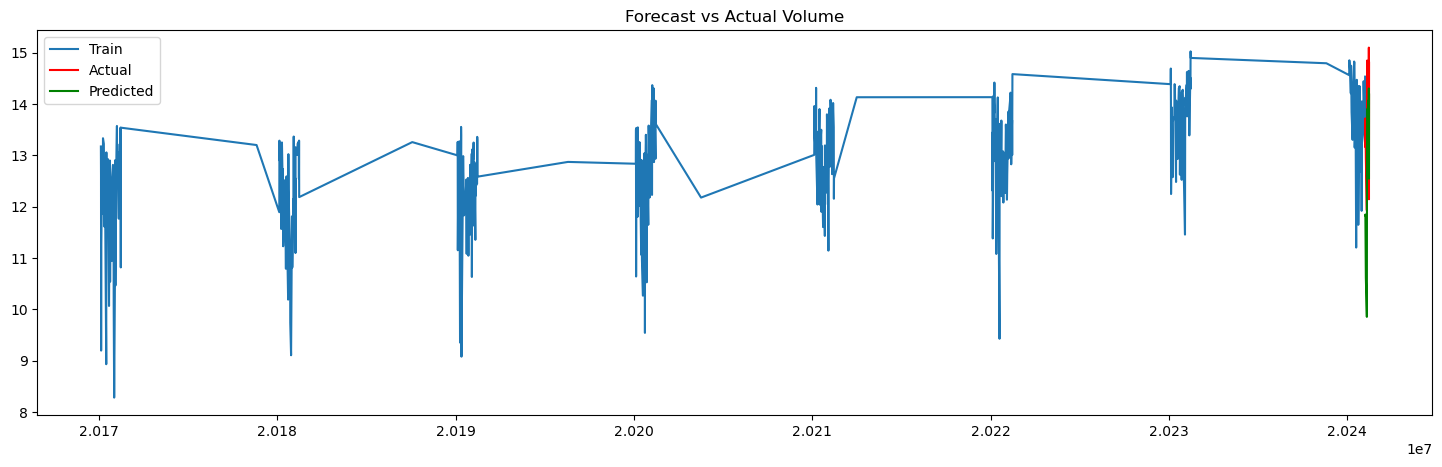

In [33]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_w, y_train_week_log, label="Train")
plt.plot(x_axis_test_w, y_test_week_log, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Daily

In [34]:
data['date2'] = pd.to_datetime(data['date'], format='ISO8601')
db_daily = data.groupby('date2').mean(numeric_only=True)
# Split into train and test set
db_daily.index = pd.to_datetime(db_daily.index)

X_day = db_daily.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC"], #are always 0 and can be ignored
                      axis=1)

#our targer variable
y_day = db_daily["volume"]
y_day_log = db_daily["log_volume"]

# Features
X_train_day = X_day[X_day.index <= '2024-11-01']
X_test_day = X_day[X_day.index > '2024-11-01']

# Label
y_train_day = y_day[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day = y_day[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

# Label log
y_train_day_log = y_day_log[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day_log = y_day_log[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data


In [35]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 10)
(60, 10)
(2862,)
(60,)
(2862,)
(60,)


In [36]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "max_capacity"]
X_train_day = X_train_day.loc[:, numeric_features]
X_test_day = X_test_day.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_day = preprocessor.fit_transform(X_train_day)
X_test_norm_day = preprocessor.fit_transform(X_test_day)

In [37]:
#add feature names back 
X_train_day = pd.DataFrame(X_train_norm_day, columns=X_train_day.columns.values, index=X_train_day.index.values)
X_test_day = pd.DataFrame(X_test_norm_day, columns = X_test_day.columns.values, index=X_test_day.index.values)
X_train_day.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,max_capacity
2017-01-01,0.288762,0.495793,0.496660,0.357645,1.639381,0.378449,-1.099395
2017-01-02,1.309003,-0.539869,-0.538402,0.809815,0.846960,1.003264,-1.099396
2017-01-03,0.827166,1.183119,1.222583,0.662124,0.866448,1.078344,-1.099396
2017-01-04,1.589490,1.388179,1.348183,0.203361,0.060603,1.222940,-1.099396
2017-01-05,-0.665349,-0.765440,-0.794530,1.758904,0.112978,-0.514666,-1.099395


In [38]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 7)
(60, 7)
(2862,)
(60,)
(2862,)
(60,)


In [39]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day.fit(X_train_day, y_train_day) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day = cv_XGB_day.best_estimator_
XGB_pred_day = XGB_model_day.predict(X_test_day)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day, XGB_pred_day))

Mean cross-validated score of the best_estimator: 0.9428763933284534
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  2934949211523.5835


In [40]:
x_axis_train_d = db_daily["year_mon_day"][:len(y_train_day)]
x_axis_test_d = db_daily["year_mon_day"][len(y_train_day):]
print(len(x_axis_train_d))
print(len(x_axis_test_d))

2862
60


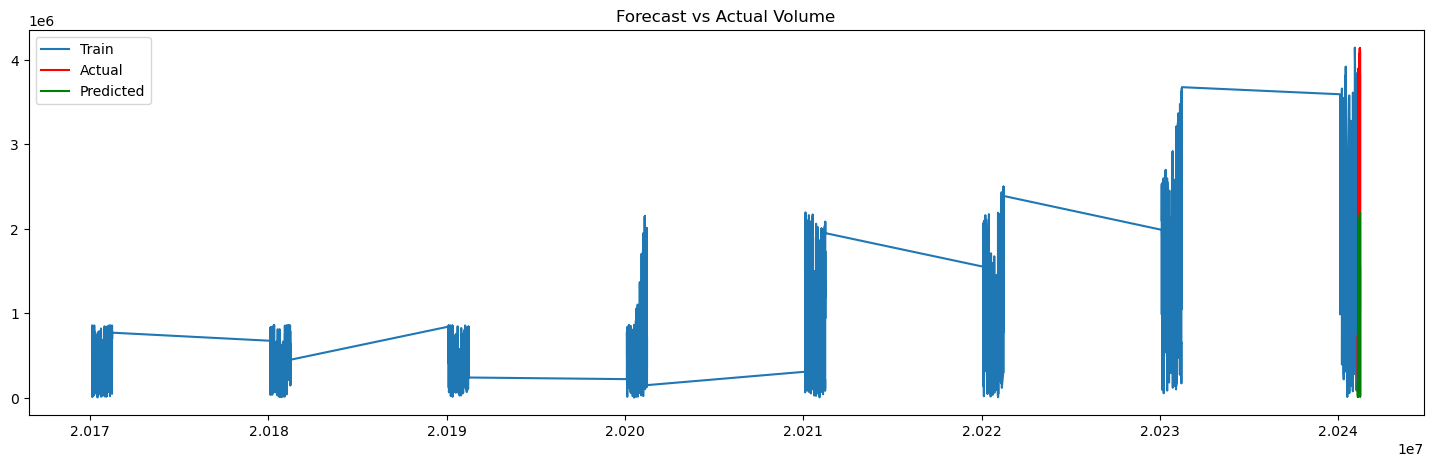

In [41]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_d, y_train_day, label="Train")
plt.plot(x_axis_test_d, y_test_day, label="Actual", color='red')
plt.plot(x_axis_test_d, XGB_pred_day, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [42]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_log.fit(X_train_day, y_train_day_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_log = cv_XGB_day_log.best_estimator_
XGB_pred_day_log = XGB_model_day_log.predict(X_test_day)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day_log, XGB_pred_day_log))

Mean cross-validated score of the best_estimator: 0.834555281382185
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  3.4018568480088125


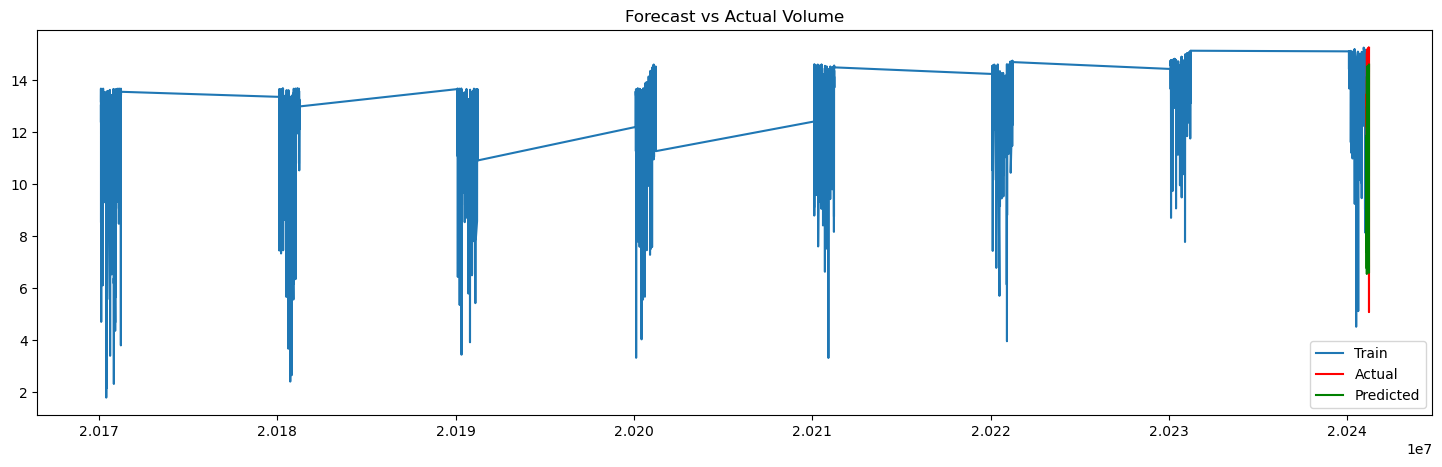

In [43]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_d, y_train_day_log, label="Train")
plt.plot(x_axis_test_d, y_test_day_log, label="Actual", color='red')
plt.plot(x_axis_test_d, XGB_pred_day_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()